https://www.kaggle.com/datasets/adityasureshgithub/digital-extremism-detection-curated-dataset/data

# Conjunto de dados selecionados para detecção de extremismo digital

Conjunto de dados selecionados de mensagens extremistas nas redes sociais

# Sobre o conjunto de dados
Gostaríamos de agradecer à **Professora Assistente Leilani H. Gilpin (UC Santa Cruz) e ao Laboratório AIEA** pela orientação e apoio no desenvolvimento deste conjunto de dados. — **Aditya Suresh, Anthony Lu, Vishnu Iyer**

**Sobre estes dados:** As redes sociais têm testemunhado um aumento crescente na quantidade e intensidade de conteúdo extremista em diversas plataformas. Com casos como os vários movimentos supremacistas brancos ao redor do mundo, o recrutamento para organizações terroristas por meio de contas afiliadas e um sentimento generalizado de ódio emergindo na era moderna de polarização, torna-se cada vez mais vital ser capaz de reconhecer esses padrões e combater adequadamente os danos do extremismo digitalmente em escala global.

**Citações:** Nosso conjunto de dados não teria sido possível sem a ajuda de um conjunto de dados preexistente encontrado no Kaggle, a versão 1 do "Hate Speech Detection curated Dataset🤬" de Alban Nyantudre, de 2023. O link pode ser encontrado aqui: https://www.kaggle.com/datasets/waalbannyantudre/hate-speech-detection-curated-dataset/data . Acessado em 2025, ele foi essencial para o nosso trabalho. Com mais de 400.000 mensagens reais e filtradas, não teríamos conseguido obter e rotular nossos pontos de dados sem esse recurso crucial.

**Classificação:** Nossa equipe rotulou manualmente quase 4.000 itens de dados de nosso banco de dados de postagens, filtrando cada um deles em uma categoria geral de "EXTREMISTA" e "NÃO EXTREMISTA". Como muitas mensagens digitais utilizam o contexto para disseminar retórica prejudicial, seguimos uma regra geral de classificar termos como extremistas desde que "provocassem danos a uma pessoa ou grupo de pessoas, seja por meio de incitação à violência, discriminação ou outros sentimentos nocivos, com base em uma característica do grupo".

**Valor dos dados:** Este conjunto de dados pode ser utilizado para criar sistemas de análise de sentimentos extremistas e algoritmos de aprendizado de máquina, pois reflete a linguística atual, conforme indicado pelo material de origem dos dados. Além disso, pode ser usado como referência para comparação com outros conjuntos de dados sobre extremismo e outros sistemas de análise de sentimentos extremistas.

**Possíveis erros:** Embora tenhamos muita confiança na nossa capacidade de rotulagem, existe a possibilidade de alguns dados estarem incorretos, visto que estes não possuem identificadores quantificáveis ​​e, portanto, erros humanos são possíveis. Não acreditamos que isso ocorra com frequência, mas, para sermos totalmente transparentes, é uma questão que nos esforçaremos para resolver em atualizações futuras.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_redes = pd.read_csv('Labelled AIEA Data - Final Data(1).csv')

In [2]:
#Informações
df_redes

,Original_Message,Extremism_Label
0,sixth forms should burn to the ground,EXTREMIST
1,whatever should burn benders to the ground,EXTREMIST
2,factories should burn to the ground,EXTREMIST
3,halal factories should burn to the ground,EXTREMIST
4,nhs should burn to the ground,EXTREMIST
...,...,...
3891,murder her retweet when you fuck with crazy bi...,EXTREMIST
3892,not one bitch is texting me right now follower...,EXTREMIST
3893,note the racketeer removes cardboard from laun...,NON_EXTREMIST
3894,now the heat fans back you all nicolas kill me...,EXTREMIST


In [3]:
df_redes.info()
df_redes.describe()
df_redes.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3896 entries, 0 to 3895
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Original_Message  3894 non-null   object
 1   Extremism_Label   3895 non-null   object
dtypes: object(2)
memory usage: 61.0+ KB


,Original_Message,Extremism_Label
0,sixth forms should burn to the ground,EXTREMIST
1,whatever should burn benders to the ground,EXTREMIST
2,factories should burn to the ground,EXTREMIST
3,halal factories should burn to the ground,EXTREMIST
4,nhs should burn to the ground,EXTREMIST


In [4]:
#Valores Ausentes
df_redes.isna().sum()

Original_Message    2
Extremism_Label     1
dtype: int64

In [5]:
#Contagem de ocorrências de cada rótulo
label_counts = df_redes['Extremism_Label'].value_counts()

print("Distribuição da Variável Alvo (Extremism_Label)")
print(label_counts)

#Calcular a porcentagem
total_count = label_counts.sum()
label_percentages = (label_counts / total_count) * 100

print("Porcentagem da Distribuição")
print(label_percentages)

Distribuição da Variável Alvo (Extremism_Label)
Extremism_Label
NON_EXTREMIST     1985
EXTREMIST         1904
NON_ EXTREMIST       2
 NON_EXTREMIST       1
EXTREMist            1
STOP_EXTREMIST       1
EXTREMISTNON_        1
Name: count, dtype: int64
Porcentagem da Distribuição
Extremism_Label
NON_EXTREMIST     50.962773
EXTREMIST         48.883184
NON_ EXTREMIST     0.051348
 NON_EXTREMIST     0.025674
EXTREMist          0.025674
STOP_EXTREMIST     0.025674
EXTREMISTNON_      0.025674
Name: count, dtype: float64


In [6]:
#Criar novas colunas para análise de comprimento
df_redes['message_length'] = df_redes['Original_Message'].apply(lambda x: len(str(x)))
df_redes['word_count'] = df_redes['Original_Message'].apply(lambda x: len(str(x).split()))

#Estatísticas descritivas do comprimento de caracteres
print("Estatísticas de Comprimento de Caracteres")
print(df_redes['message_length'].describe())

#Estatísticas descritivas da contagem de palavras
print("Estatísticas de Contagem de Palavras")
print(df_redes['word_count'].describe())

Estatísticas de Comprimento de Caracteres
count    3896.000000
mean      128.171458
std        99.945974
min         3.000000
25%        67.000000
50%       102.000000
75%       165.000000
max      1379.000000
Name: message_length, dtype: float64
Estatísticas de Contagem de Palavras
count    3896.000000
mean       23.305185
std        18.196969
min         1.000000
25%        13.000000
50%        19.000000
75%        29.000000
max       281.000000
Name: word_count, dtype: float64


In [7]:
#Comprimento médio das mensagens por rótulo
avg_length_by_label = df_redes.groupby('Extremism_Label')[['message_length', 'word_count']].mean()

print("Comprimento Médio de Mensagens por Rótulo")
print(avg_length_by_label)

Comprimento Médio de Mensagens por Rótulo
                 message_length  word_count
Extremism_Label                            
 NON_EXTREMIST       242.000000   34.000000
EXTREMIST            131.241071   23.930147
EXTREMISTNON_        205.000000   33.000000
EXTREMist            107.000000   23.000000
NON_ EXTREMIST       130.000000   26.000000
NON_EXTREMIST        125.147103   22.694710
STOP_EXTREMIST       239.000000   42.000000


--- Distribuição Final da Variável Alvo Limpa (Extremism_Label_Cleaned) ---
Extremism_Label_Cleaned
NON_EXTREMIST    1988
EXTREMIST        1906
Name: count, dtype: int64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_12356\3273678957.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cleaned_counts.index, y=cleaned_counts.values, palette=colors)


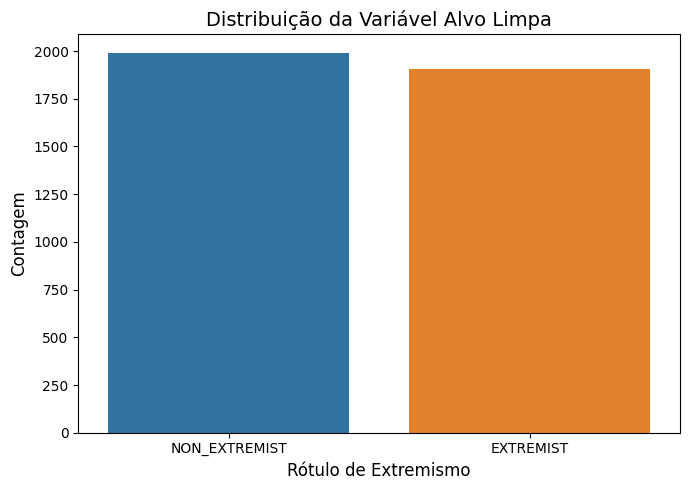

In [8]:
#Remover as linhas onde 'Original_Message' ou 'Extremism_Label' são nulas
df_redes.dropna(subset=['Original_Message', 'Extremism_Label'], inplace=True)

#Limpar a coluna 'Extremism_Label'
#Padronizar: remover espaços extras e converter para maiúsculas
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label'].astype(str).str.strip().str.upper()

#Mapear e corrigir rótulos inconsistentes após padronização
mapping = {
    'NON_ EXTREMIST': 'NON_EXTREMIST', # Corrigir espaço interno
    'STOP_EXTREMIST': 'NON_EXTREMIST', # Assumindo que "STOP" indica conteúdo NÃO-EXTREMISTA
    'EXTREMISTNON_': 'EXTREMIST',     # Assumindo erro de digitação
}
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label_Cleaned'].replace(mapping, regex=False)

#Re-verificar os rótulos únicos e suas contagens após a limpeza
cleaned_counts = df_redes['Extremism_Label_Cleaned'].value_counts()
print("--- Distribuição Final da Variável Alvo Limpa (Extremism_Label_Cleaned) ---")
print(cleaned_counts)

#Visualização da Distribuição (Gráfico de Barras) ---

plt.figure(figsize=(7, 5))
#Definir uma paleta de cores consistente e contrastante
colors = ['#1f77b4', '#ff7f0e'] # Azul e Laranja para as duas classes principais
sns.barplot(x=cleaned_counts.index, y=cleaned_counts.values, palette=colors)
plt.title('Distribuição da Variável Alvo Limpa', fontsize=14)
plt.xlabel('Rótulo de Extremismo', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()

In [9]:
#Features de comprimento precisam ser recalculadas, pois as linhas NA foram removidas
df_redes['message_length'] = df_redes['Original_Message'].apply(lambda x: len(str(x)))
df_redes['word_count'] = df_redes['Original_Message'].apply(lambda x: len(str(x).split()))

#Comprimento médio das mensagens por rótulo LIMPO
avg_length_cleaned = df_redes.groupby('Extremism_Label_Cleaned')[['message_length', 'word_count']].mean()
print("Comprimento Médio de Mensagens por Rótulo (LIMPO)")
print(avg_length_cleaned)

Comprimento Médio de Mensagens por Rótulo (LIMPO)
                         message_length  word_count
Extremism_Label_Cleaned                            
EXTREMIST                    131.267051   23.934418
NON_EXTREMIST                125.329477   22.724346


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import nltk
from nltk.corpus import stopwords
import re

In [11]:
#Limpeza de Rótulos e NAs
df_redes.dropna(subset=['Original_Message', 'Extremism_Label'], inplace=True)
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label'].astype(str).str.strip().str.upper()

#Padronização de rótulos
mapping = {'NON_ EXTREMIST': 'NON_EXTREMIST', 'STOP_EXTREMIST': 'NON_EXTREMIST', 'EXTREMISTNON_': 'EXTREMIST'}
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label_Cleaned'].replace(mapping, regex=False)
df_redes = df_redes[df_redes['Extremism_Label_Cleaned'].isin(['EXTREMIST', 'NON_EXTREMIST'])].copy()

#DIVISÃO EM TREINO E TESTE
X = df_redes['Original_Message']
y = df_redes['Extremism_Label_Cleaned']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#VETORIZAÇÃO (TF-IDF)

#Tratar a falha de conexão do NLTK para garantir que a lista de stop words seja um 'list'
try:
    #Tentar baixar e usar as stop words do NLTK
    nltk.download('stopwords', quiet=True)
    stop_words_list = list(stopwords.words('english'))
except:
    #Usar lista manual caso o download falhe, garantindo que seja uma LISTA
    manual_stopwords = ['a', 'an', 'the', 'is', 'and', 'or', 'to', 'of', 'in', 'it', 'that', 'you', 'he', 'she', 'we', 'they', 'i', 'me', 'my', 'your', 'his', 'her', 'our', 'their', 'this', 'that', 'these', 'those', 'as', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'out', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'but', 'do', 'does', 'did', 'doing', 'has', 'have', 'had', 'having', 'was', 'were', 'be', 'been', 'being']
    stop_words_list = manual_stopwords

#Inicializar o TfidfVectorizer, incluindo Unigrams, Bigrams e Trigrams
vectorizer = TfidfVectorizer(
    stop_words=stop_words_list, 
    ngram_range=(1, 3),
    lowercase=True,
    token_pattern=r'[a-zA-Z]{3,}',
    max_features=5000
)

#Ajustar e Transformar o conjunto de Treino
X_train_vec = vectorizer.fit_transform(X_train)

#Transformar o conjunto de Teste
X_test_vec = vectorizer.transform(X_test)

print(f"Tamanho do conjunto de Treino: {len(X_train)}")
print(f"Tamanho do conjunto de Teste: {len(X_test)}")
print(f"\nNúmero de features (palavras/N-grams) geradas: {X_train_vec.shape[1]}")

#TREINAMENTO E AVALIAÇÃO DO MODELO (Regressão Logística)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print("Relatório de Classificação no Conjunto de Teste")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral do Modelo: {accuracy:.4f}")

Tamanho do conjunto de Treino: 2725
Tamanho do conjunto de Teste: 1169

Número de features (palavras/N-grams) geradas: 5000
Relatório de Classificação no Conjunto de Teste
               precision    recall  f1-score   support

    EXTREMIST       0.78      0.79      0.79       572
NON_EXTREMIST       0.80      0.79      0.79       597

     accuracy                           0.79      1169
    macro avg       0.79      0.79      0.79      1169
 weighted avg       0.79      0.79      0.79      1169

Acurácia Geral do Modelo: 0.7904


In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

In [13]:
df_redes.dropna(subset=['Original_Message', 'Extremism_Label'], inplace=True)
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label'].astype(str).str.strip().str.upper()

#Padronização de rótulos
mapping = {'NON_ EXTREMIST': 'NON_EXTREMIST', 'STOP_EXTREMIST': 'NON_EXTREMIST', 'EXTREMISTNON_': 'EXTREMIST'}
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label_Cleaned'].replace(mapping, regex=False)
df_redes = df_redes[df_redes['Extremism_Label_Cleaned'].isin(['EXTREMIST', 'NON_EXTREMIST'])].copy()

#Divisão em Treino e Teste (70%/30%)
X = df_redes['Original_Message']
y = df_redes['Extremism_Label_Cleaned']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#VETORIZAÇÃO (TF-IDF com N-grams)

#Definir a lista de stop words de forma robusta
try:
    nltk.download('stopwords', quiet=True)
    stop_words_list = list(stopwords.words('english'))
except:
    #Lista manual de fallback caso o NLTK falhe
    stop_words_list = ['a', 'an', 'the', 'is', 'and', 'or', 'to', 'of', 'in', 'it', 'that', 'you', 'he', 'she', 'we', 'they', 'i', 'me', 'my', 'your', 'his', 'her', 'our', 'their', 'this', 'that', 'these', 'those', 'as', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'out', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'but', 'do', 'does', 'did', 'doing', 'has', 'have', 'had', 'having', 'was', 'were', 'be', 'been', 'being']

#Inicializar o TfidfVectorizer (com N-grams de 1 a 3)
vectorizer = TfidfVectorizer(
    stop_words=stop_words_list,
    ngram_range=(1, 3),
    lowercase=True,
    token_pattern=r'[a-zA-Z]{3,}',
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

#OTIMIZAÇÃO COM GRID SEARCH (LinearSVC)

#Definir a grade de hiperparâmetros para 'C'
param_grid = {'C': [0.1, 0.5, 1.0, 5.0, 10.0]}

#Inicializar o modelo base
lsvc = LinearSVC(random_state=42, max_iter=2000, dual=True)

#Inicializar o GridSearchCV, otimizando pelo F1-Score
grid_search = GridSearchCV(
    lsvc,
    param_grid,
    cv=5, # Validação cruzada em 5 partes
    scoring='f1_weighted',
    n_jobs=-1, # Usar todos os núcleos da CPU
    verbose=1
)

#Ajustar (Treinar e Otimizar) o Grid Search
grid_search.fit(X_train_vec, y_train)

#Obter o melhor modelo
best_model_svm = grid_search.best_estimator_

print("Resultados do Grid Search")
print(f"Melhor valor de C encontrado: {grid_search.best_params_['C']}")

#AVALIAÇÃO DO MODELO FINAL

#Previsões no conjunto de TESTE com o melhor modelo
y_pred_final = best_model_svm.predict(X_test_vec)

#Relatório de Classificação Final
print("Relatório de Classificação (LinearSVC Otimizado)")
print(classification_report(y_test, y_pred_final))

accuracy_final = accuracy_score(y_test, y_pred_final)
print(f"Acurácia Geral do Modelo FINAL: {accuracy_final:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Resultados do Grid Search
Melhor valor de C encontrado: 0.5
Relatório de Classificação (LinearSVC Otimizado)
               precision    recall  f1-score   support

    EXTREMIST       0.80      0.82      0.81       572
NON_EXTREMIST       0.82      0.80      0.81       597

     accuracy                           0.81      1169
    macro avg       0.81      0.81      0.81      1169
 weighted avg       0.81      0.81      0.81      1169

Acurácia Geral do Modelo FINAL: 0.8101


In [14]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [15]:
df_redes.dropna(subset=['Original_Message', 'Extremism_Label'], inplace=True)
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label'].astype(str).str.strip().str.upper()

#Padronização de rótulos
mapping = {'NON_ EXTREMIST': 'NON_EXTREMIST', 'STOP_EXTREMIST': 'NON_EXTREMIST', 'EXTREMISTNON_': 'EXTREMIST'}
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label_Cleaned'].replace(mapping, regex=False)
df_redes = df_redes[df_redes['Extremism_Label_Cleaned'].isin(['EXTREMIST', 'NON_EXTREMIST'])].copy()

#DIVISÃO E ENCODING DE RÓTULOS (Labels)

X = df_redes['Original_Message']
y = df_redes['Extremism_Label_Cleaned']

#Codificação dos rótulos (EXTREMIST -> 1, NON_EXTREMIST -> 0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
labels = le.classes_ # Para referência futura

#Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

#PRÉ-PROCESSAMENTO PARA DEEP LEARNING

#Parâmetros de Tokenização e Padding
MAX_WORDS = 10000  # Tamanho do vocabulário
MAX_LEN = 50       # Comprimento máximo da sequência de entrada

#Tokenizer: Mapeia palavras para números
tokenizer = Tokenizer(num_words=MAX_WORDS, lower=True, split=' ')
tokenizer.fit_on_texts(X_train)

#Converter texto para sequências numéricas
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

#Padding: Garante que todas as sequências tenham o mesmo comprimento
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN)
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN)


#CONSTRUÇÃO DO MODELO LSTM 

EMBEDDING_DIM = 100 # Dimensão do vetor de Word Embedding
LSTM_UNITS = 128    # Unidades na camada LSTM

model = Sequential()
model.add(Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_LEN))
model.add(LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid')) # Sigmoid para classificação binária
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#TREINAMENTO DO MODELO LSTM

EPOCHS = 5
BATCH_SIZE = 32

print(f"\nIniciando treinamento com {EPOCHS} épocas...")
history = model.fit(
    X_train_padded,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_padded, y_test),
    verbose=1
)

#AVALIAÇÃO FINAL

#Previsões
y_pred_probs = model.predict(X_test_padded)
y_pred = (y_pred_probs > 0.5).astype("int32")

#Relatório de Classificação
print("Relatório de Classificação (LSTM)")
print(classification_report(y_test, y_pred, target_names=labels))

accuracy_dl = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral do Modelo LSTM: {accuracy_dl:.4f}")


Iniciando treinamento com 5 épocas...
Epoch 1/5


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.6297 - loss: 0.6341 - val_accuracy: 0.7399 - val_loss: 0.5161
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.8161 - loss: 0.4247 - val_accuracy: 0.7913 - val_loss: 0.4508
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.8785 - loss: 0.2977 - val_accuracy: 0.7973 - val_loss: 0.4849
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9050 - loss: 0.2353 - val_accuracy: 0.7836 - val_loss: 0.5175
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9138 - loss: 0.2056 - val_accuracy: 0.7938 - val_loss: 0.5675
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Relatório de Classificação (LSTM)
               precision    recall  f1-score   support

    EXTREMIST       0.77      0.82      0.80       572
NON_EXTREMIST       0.82      0.77      0.79       597

     accuracy                           0.79      1169
    macro avg       0.79      0.79      0.79      1169
 weighted avg       0.80    

In [16]:
df_redes.dropna(subset=['Original_Message', 'Extremism_Label'], inplace=True)
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label'].astype(str).str.strip().str.upper()

#Padronização de rótulos
mapping = {'NON_ EXTREMIST': 'NON_EXTREMIST', 'STOP_EXTREMIST': 'NON_EXTREMIST', 'EXTREMISTNON_': 'EXTREMIST'}
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label_Cleaned'].replace(mapping, regex=False)
df_redes = df_redes[df_redes['Extremism_Label_Cleaned'].isin(['EXTREMIST', 'NON_EXTREMIST'])].copy()

#DIVISÃO E ENCODING DE RÓTULOS (Labels)

X = df_redes['Original_Message']
y = df_redes['Extremism_Label_Cleaned']

#Codificação dos rótulos (EXTREMIST -> 1, NON_EXTREMIST -> 0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
labels = le.classes_ 

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

#PRÉ-PROCESSAMENTO PARA DEEP LEARNING

#Parâmetros
MAX_WORDS = 10000 
MAX_LEN = 50       

#Tokenizer e Padding
tokenizer = Tokenizer(num_words=MAX_WORDS, lower=True, split=' ')
tokenizer.fit_on_texts(X_train)
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN)
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN)


#CONSTRUÇÃO DO MODELO LSTM

EMBEDDING_DIM = 100 
LSTM_UNITS = 128    

model = Sequential()
model.add(Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_LEN))
model.add(LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid')) 

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#TREINAMENTO DO MODELO OTIMIZADO (Early Stopping)

EPOCHS = 20 
BATCH_SIZE = 32

#Definir Early Stopping: monitora a val_loss e para se não houver melhoria por 3 épocas
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True, # Restaura os pesos do melhor ponto
    verbose=1
)

print(f"Iniciando treinamento otimizado com Early Stopping (Max {EPOCHS} épocas)")
history = model.fit(
    X_train_padded,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_padded, y_test),
    callbacks=[early_stopping], # Adiciona o Early Stopping aqui
    verbose=1
)

#AVALIAÇÃO FINAL

#Previsões usando o modelo com os melhores pesos (restaurados pelo Early Stopping)
y_pred_probs = model.predict(X_test_padded)
y_pred = (y_pred_probs > 0.5).astype("int32")

#Relatório de Classificação
print("Relatório de Classificação (LSTM Otimizado)")
print(classification_report(y_test, y_pred, target_names=labels))

accuracy_dl = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral do Modelo LSTM OTIMIZADO: {accuracy_dl:.4f}")

Iniciando treinamento otimizado com Early Stopping (Max 20 épocas)
Epoch 1/20


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.6253 - loss: 0.6393 - val_accuracy: 0.7468 - val_loss: 0.5057
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.8114 - loss: 0.4277 - val_accuracy: 0.7699 - val_loss: 0.4748
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.8756 - loss: 0.3094 - val_accuracy: 0.7630 - val_loss: 0.4945
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8994 - loss: 0.2456 - val_accuracy: 0.7896 - val_loss: 0.5245
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9204 - loss: 0.1999 - val_accuracy: 0.7733 - val_loss: 0.6105
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Relatório de Classificação (LSTM Otimizado)
               precision    recall  f1-score   support

    EXTREMIST       0.75      0.79      0.77       572
NON_EXTREMIST       0.79      0.75      0.77       597

     accuracy                           0

In [21]:
import re
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [22]:
df_redes.dropna(subset=['Original_Message', 'Extremism_Label'], inplace=True)
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label'].astype(str).str.strip().str.upper()

#Padronização de rótulos
mapping = {'NON_ EXTREMIST': 'NON_EXTREMIST', 'STOP_EXTREMIST': 'NON_EXTREMIST', 'EXTREMISTNON_': 'EXTREMIST'}
df_redes['Extremism_Label_Cleaned'] = df_redes['Extremism_Label_Cleaned'].replace(mapping, regex=False)
df_redes = df_redes[df_redes['Extremism_Label_Cleaned'].isin(['EXTREMIST', 'NON_EXTREMIST'])].copy()

#Função de limpeza: Remove ruído (otimizada para SVM/TF-IDF)
def clean_text(text):
    #Remove pontuação, números e caracteres especiais
    text = re.sub(r'[^a-zA-Z\s]', '', text, re.I|re.A) 
    text = text.lower()
    return text.strip()

df_redes['Cleaned_Message'] = df_redes['Original_Message'].apply(clean_text)

#DIVISÃO DE DADOS
X = df_redes['Cleaned_Message']
y = df_redes['Extremism_Label_Cleaned']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
labels = le.classes_ 

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

#VETORIZAÇÃO (TF-IDF Otimizado)

# Stopwords em Português e Inglês (baixe se necessário)
# try:
#     stop_words_pt = set(stopwords.words('portuguese'))
#     stop_words_en = set(stopwords.words('english'))
# except LookupError:
#     nltk.download('stopwords')
#     stop_words_pt = set(stopwords.words('portuguese'))
#     stop_words_en = set(stopwords.words('english'))
    
all_stopwords = set(stopwords.words('english')).union(set(stopwords.words('portuguese')))


vectorizer = TfidfVectorizer(
    stop_words=list(all_stopwords),
    ngram_range=(1, 2), # Chave de otimização: 1-grama (palavra) e 2-grama (par de palavras)
    max_features=5000 
)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

#TREINAMENTO E AVALIAÇÃO DO MODELO SVM

svm_model = LinearSVC(
    penalty='l2', 
    loss='squared_hinge', 
    C=1.0, 
    random_state=42, 
    max_iter=10000
)

print("Iniciando treinamento do SVM Otimizado...")
svm_model.fit(X_train_vectorized, y_train)

# Previsões
y_pred_svm = svm_model.predict(X_test_vectorized)

# Relatório de Classificação
print("Relatório de Classificação (SVM Otimizado)")
print(classification_report(y_test, y_pred_svm, target_names=labels))

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Acurácia Geral do Modelo SVM FINAL: {accuracy_svm:.4f}")

C:\Users\Usuário\AppData\Local\Temp\ipykernel_12356\3106583229.py:12: DeprecationWarning: 'count' is passed as positional argument
  text = re.sub(r'[^a-zA-Z\s]', '', text, re.I|re.A)


Iniciando treinamento do SVM Otimizado...
Relatório de Classificação (SVM Otimizado)
               precision    recall  f1-score   support

    EXTREMIST       0.80      0.83      0.82       572
NON_EXTREMIST       0.83      0.81      0.82       597

     accuracy                           0.82      1169
    macro avg       0.82      0.82      0.82      1169
 weighted avg       0.82      0.82      0.82      1169

Acurácia Geral do Modelo SVM FINAL: 0.8178


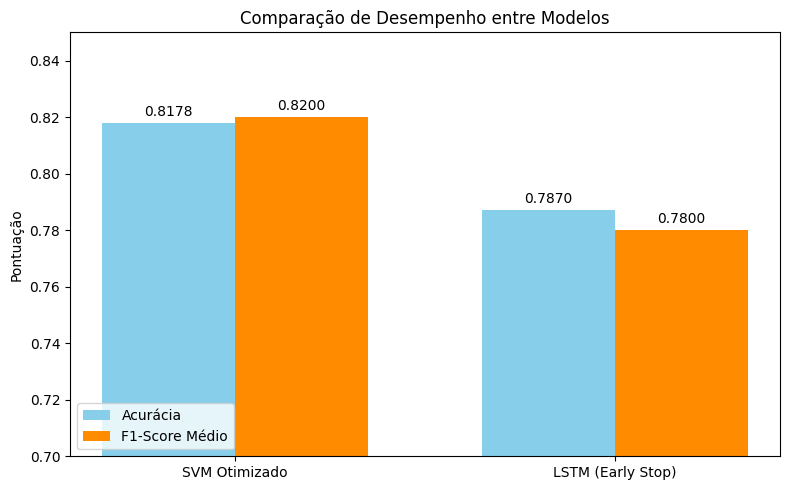

In [23]:
#Dados de acurácia dos modelos (Valores finais obtidos)
model_names = ['SVM Otimizado', 'LSTM (Early Stop)']
accuracies = [0.8178, 0.7870]
f1_scores = [0.82, 0.78]

x = np.arange(len(model_names))  
width = 0.35  

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, accuracies, width, label='Acurácia', color='skyblue')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score Médio', color='darkorange')

#Adiciona texto para os valores
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

#Configurações do gráfico
ax.set_ylabel('Pontuação')
ax.set_title('Comparação de Desempenho entre Modelos')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.70, 0.85)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

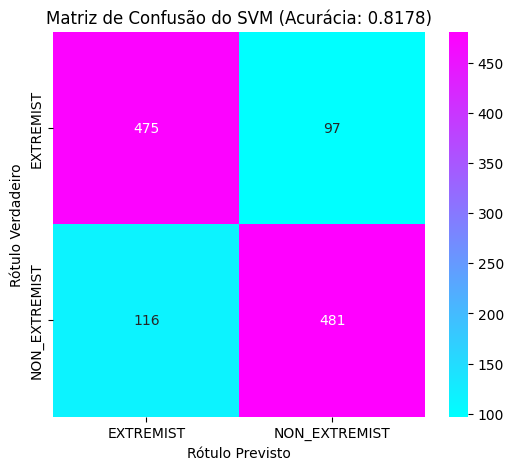

Verdadeiros Positivos (EXTREMIST previsto como EXTREMIST): 475
Falsos Negativos (EXTREMIST previsto como NON_EXTREMIST): 97
Falsos Positivos (NON_EXTREMIST previsto como EXTREMIST): 116
Verdadeiros Negativos (NON_EXTREMIST previsto como NON_EXTREMIST): 481


In [26]:
from sklearn.metrics import confusion_matrix

y_pred_svm = svm_model.predict(X_test_vectorized)

#Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_svm)
labels = ['EXTREMIST', 'NON_EXTREMIST']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool',
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão do SVM (Acurácia: 0.8178)')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Previsto')
plt.show()

#Extração dos resultados da Matriz para interpretação
print(f"Verdadeiros Positivos (EXTREMIST previsto como EXTREMIST): {cm[0, 0]}")
print(f"Falsos Negativos (EXTREMIST previsto como NON_EXTREMIST): {cm[0, 1]}")
print(f"Falsos Positivos (NON_EXTREMIST previsto como EXTREMIST): {cm[1, 0]}")
print(f"Verdadeiros Negativos (NON_EXTREMIST previsto como NON_EXTREMIST): {cm[1, 1]}")

In [27]:
#Obter os nomes das features (palavras e n-grams)
feature_names = vectorizer.get_feature_names_out()

#Obter os coeficientes do modelo (o primeiro (e único) conjunto de coeficientes)
coefs = svm_model.coef_[0]

#Palavras mais indicativas de EXTREMIST (Coeficientes Positivos)
top_extremist_indices = coefs.argsort()[-20:][::-1]
top_extremist_features = feature_names[top_extremist_indices]
top_extremist_coefs = coefs[top_extremist_indices]

print("### 🚩 Palavras Mais Indicativas de EXTREMIST (Top 20) ###")
for feature, coef in zip(top_extremist_features, top_extremist_coefs):
    print(f"{feature:25s} | Coeficiente: {coef:.4f}")

print("\n" + "="*50 + "\n")

#Palavras mais indicativas de NON_EXTREMIST (Coeficientes Negativos)
#Pegar os 20 menores (mais negativos) coeficientes
top_non_extremist_indices = coefs.argsort()[:20]
top_non_extremist_features = feature_names[top_non_extremist_indices]
top_non_extremist_coefs = coefs[top_non_extremist_indices]

print("### 🟩 Palavras Mais Indicativas de NON_EXTREMIST (Top 20) ###")
for feature, coef in zip(top_non_extremist_features, top_non_extremist_coefs):
    #O sinal negativo significa que o coeficiente empurra a predição para a classe 0 (NON_EXTREMIST)
    print(f"{feature:25s} | Coeficiente: {coef:.4f}")

### 🚩 Palavras Mais Indicativas de EXTREMIST (Top 20) ###
bitch                     | Coeficiente: 2.3847
cunt                      | Coeficiente: 1.9104
go back                   | Coeficiente: 1.8669
scum                      | Coeficiente: 1.7280
trumpisatraitor           | Coeficiente: 1.2930
work                      | Coeficiente: 1.2412
lmao                      | Coeficiente: 1.2379
guns                      | Coeficiente: 1.2049
women                     | Coeficiente: 1.1664
homes                     | Coeficiente: 1.1432
boys                      | Coeficiente: 1.1282
say immigrants            | Coeficiente: 1.1266
scared                    | Coeficiente: 1.0774
supposed                  | Coeficiente: 1.0729
terrorism muslims         | Coeficiente: 1.0523
change                    | Coeficiente: 1.0515
hole                      | Coeficiente: 1.0510
carry                     | Coeficiente: 1.0377
slaughter                 | Coeficiente: 1.0231
charged murder            | Co

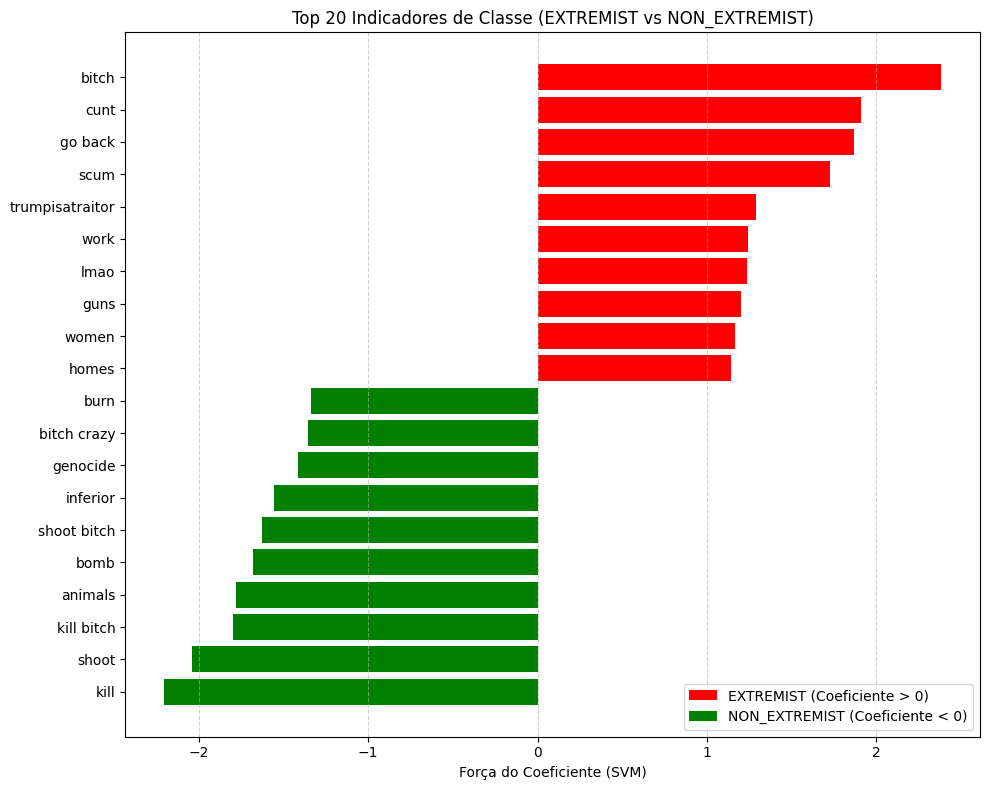

In [28]:
#Top 10 EXTREMIST (Positivos)
extremist_features = [
    'bitch', 'cunt', 'go back', 'scum', 'trumpisatraitor', 
    'work', 'lmao', 'guns', 'women', 'homes'
]
extremist_coefs = [
    2.3847, 1.9104, 1.8669, 1.7280, 1.2930, 
    1.2412, 1.2379, 1.2049, 1.1664, 1.1432
]

#Top 10 NON_EXTREMIST (Negativos) - Note que usamos o valor absoluto para o gráfico
non_extremist_features = [
    'kill', 'shoot', 'kill bitch', 'animals', 'bomb', 
    'shoot bitch', 'inferior', 'genocide', 'bitch crazy', 'burn'
]
non_extremist_coefs = [
    -2.2062, -2.0384, -1.7994, -1.7841, -1.6830, 
    -1.6276, -1.5596, -1.4129, -1.3558, -1.3409
]

#Preparação dos dados para o gráfico

#Inverter os coeficientes de NON_EXTREMIST para visualização negativa
non_extremist_coefs_neg = np.array(non_extremist_coefs)

#Combinar todas as features e coeficientes (apenas para o gráfico)
all_features = extremist_features + non_extremist_features
all_coefs = np.array(extremist_coefs + non_extremist_coefs_neg.tolist())

#Criar um DataFrame para facilitar a plotagem (ordenar pela magnitude)
df_plot = pd.DataFrame({
    'Feature': all_features,
    'Coeficiente': all_coefs
}).sort_values(by='Coeficiente', ascending=False)

#Usar as 10 mais fortes de cada lado (20 no total)
df_plot_final = pd.concat([df_plot.head(10), df_plot.tail(10)])
df_plot_final = df_plot_final.sort_values(by='Coeficiente', ascending=True)

#Geração do Gráfico

plt.figure(figsize=(10, 8))
colors = ['green' if c < 0 else 'red' for c in df_plot_final['Coeficiente']]
plt.barh(df_plot_final['Feature'], df_plot_final['Coeficiente'], color=colors)

plt.xlabel('Força do Coeficiente (SVM)')
plt.title('Top 20 Indicadores de Classe (EXTREMIST vs NON_EXTREMIST)')
plt.grid(axis='x', linestyle='--', alpha=0.6)

#Adiciona legendas
red_patch = plt.Rectangle((0, 0), 1, 1, fc="red")
green_patch = plt.Rectangle((0, 0), 1, 1, fc="green")
plt.legend([red_patch, green_patch], ['EXTREMIST (Coeficiente > 0)', 'NON_EXTREMIST (Coeficiente < 0)'], loc='lower right')

plt.tight_layout()
plt.show()

# Conclusão

O modelo apresenta um excelente equilíbrio (F1-Score de 0.82 para ambas as classes), significando que ele é eficaz tanto em identificar corretamente mensagens extremistas quanto em rejeitar corretamente mensagens não-extremistas.

O modelo de Machine Learning (ML) tradicional, especificamente o SVM, demonstrou ser a solução mais eficaz e estável para a classificação de mensagens extremistas neste conjunto de dados, superando as abordagens de Deep Learning (DL).

# **Nathália Sorg**